📊 San Francisco Employee Compensation Analysis

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

Load Dataset

In [102]:
df = pd.read_csv('san fransico employee salaries.csv', low_memory=False)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (312882, 9)
        EmployeeName                                        JobTitle  \
0     NATHANIEL FORD  GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY   
1       GARY JIMENEZ                 CAPTAIN III (POLICE DEPARTMENT)   
2     ALBERT PARDINI                 CAPTAIN III (POLICE DEPARTMENT)   
3  CHRISTOPHER CHONG            WIRE ROPE CABLE MAINTENANCE MECHANIC   
4    PATRICK GARDNER    DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)   

     BasePay OvertimePay   OtherPay      Benefits   TotalPay  \
0  167411.18        0.00  400184.25  Not Provided  567595.43   
1  155966.02   245131.88  137811.38  Not Provided  538909.28   
2  212739.13   106088.18   16452.60  Not Provided  335279.91   
3   77916.00    56120.71  198306.90  Not Provided  332343.61   
4  134401.60     9737.00  182234.59  Not Provided  326373.19   

   TotalPayBenefits  Year  
0         567595.43  2011  
1         538909.28  2011  
2         335279.91  2011  
3         332343.61  2011  
4         32637

Convert salary columns to numeric

In [103]:
cols = ['BasePay', 'OvertimePay', 'OtherPay', 'Benefits']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Missing values after conversion:")
print(df[cols].isnull().sum())

Missing values after conversion:
BasePay          606
OvertimePay        1
OtherPay           1
Benefits       36160
dtype: int64


Duplicate rows


In [104]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0


Drop rows where Total Pay and Total Pay Benefits are missing

In [105]:
df = df.dropna(subset=['TotalPay', 'TotalPayBenefits'])

Fill missing Benefits with 0

In [106]:
df['Benefits'] = df['Benefits'].fillna(0)

Feature Engineering

 Overtime ratio

In [107]:
df['OvertimeRatio'] = np.where(df['TotalPay'] > 0,
                               df['OvertimePay'] / df['TotalPay'],
                               0)


 Benefits ratio

In [108]:
df['BenefitsRatio'] = df['Benefits'] / df['TotalPayBenefits']

Exploratory Data Analysis

Distribution of Total Pay

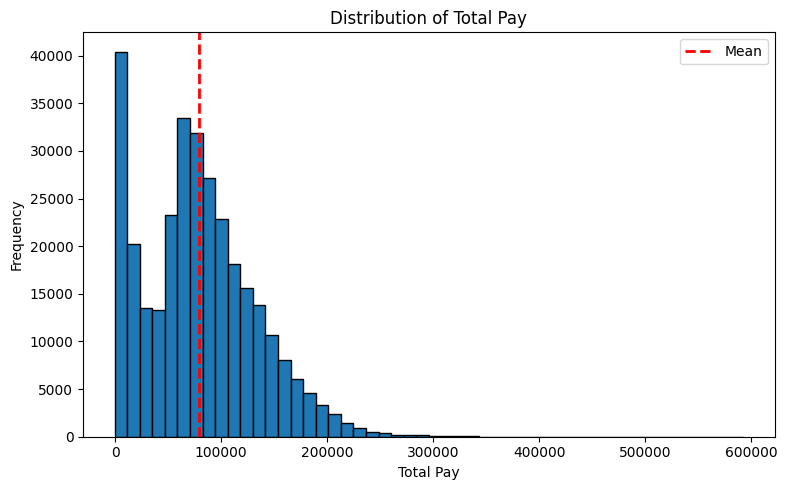

In [109]:
plt.figure(figsize=(8,5))
plt.hist(df['TotalPay'], bins=50, edgecolor='black')
plt.axvline(df['TotalPay'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.title('Distribution of Total Pay')
plt.xlabel('Total Pay')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

 Average Total Pay by Year

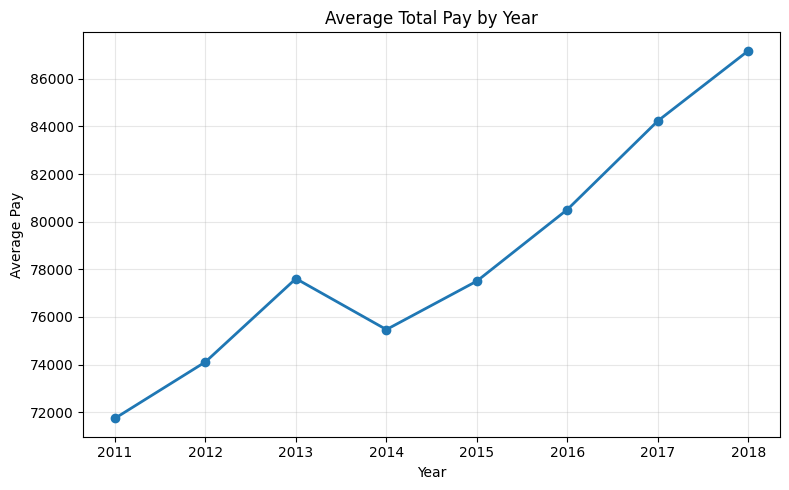

In [110]:
plt.figure(figsize=(8,5))
plt.plot(yearly_pay.index, yearly_pay.values, marker='o', linewidth=2)
plt.title('Average Total Pay by Year')
plt.xlabel('Year')
plt.ylabel('Average Pay')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Top 10 Highest Paying Job Titles

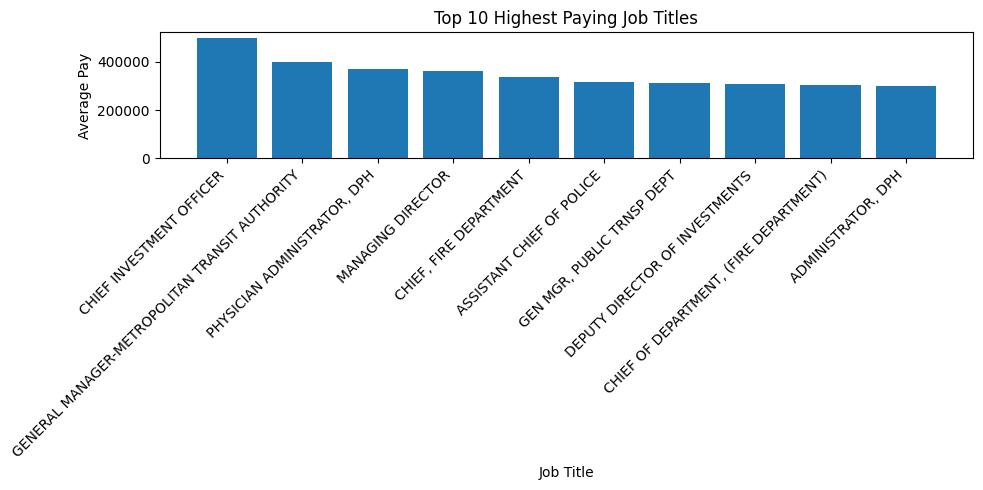

In [111]:
df['JobTitle'] = df['JobTitle'].astype(str).str.upper().str.strip()
top_jobs = df.groupby('JobTitle')['TotalPay'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(top_jobs.index, top_jobs.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Highest Paying Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Average Pay')
plt.tight_layout()
plt.show()

Top Overtime Jobs

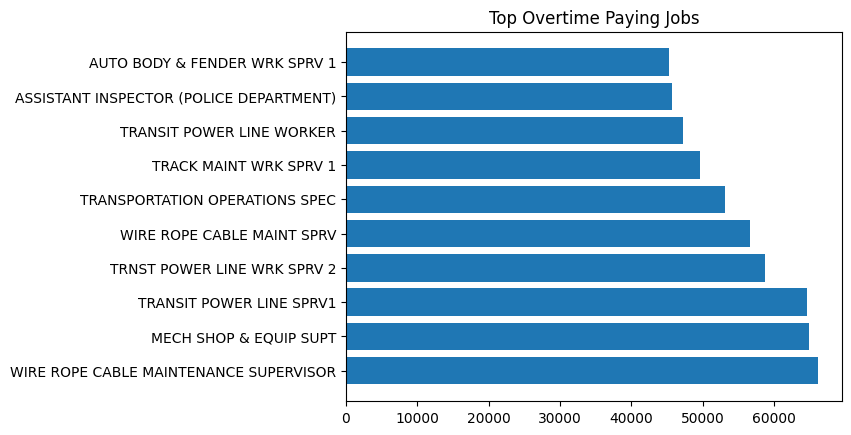

In [113]:
top_ot = df.groupby('JobTitle')['OvertimePay'].mean().sort_values(ascending=False).head(10)
plt.barh(top_ot.index, top_ot.values)
plt.title('Top Overtime Paying Jobs')
plt.show()

Employee Count by Year

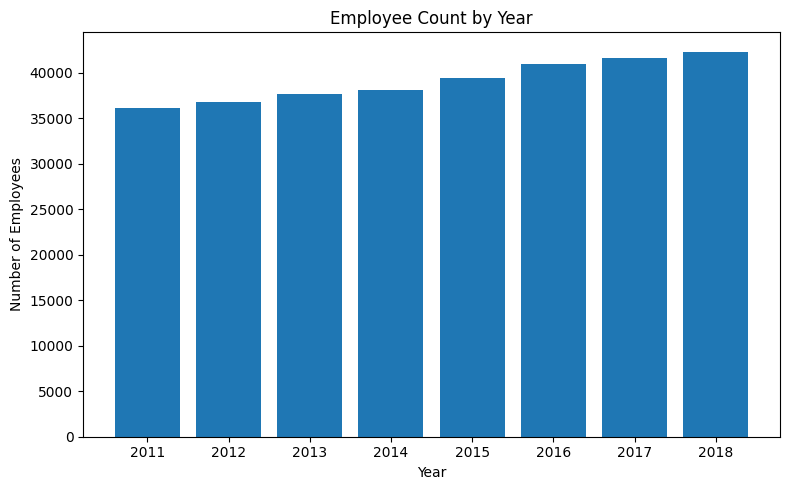

In [114]:
year_count = df.groupby('Year')['EmployeeName'].count()

plt.figure(figsize=(8,5))
plt.bar(year_count.index, year_count.values)
plt.title('Employee Count by Year')
plt.xlabel('Year')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

Pay Components Comparison

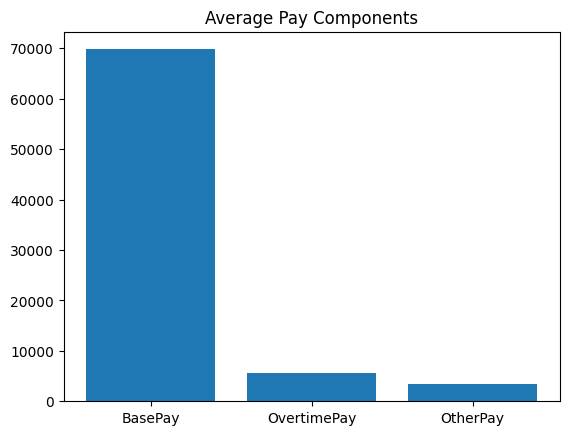

In [125]:
components = df[['BasePay','OvertimePay','OtherPay']].mean()
plt.bar(components.index, components.values)
plt.title('Average Pay Components')
plt.show()

 Overtime Trend

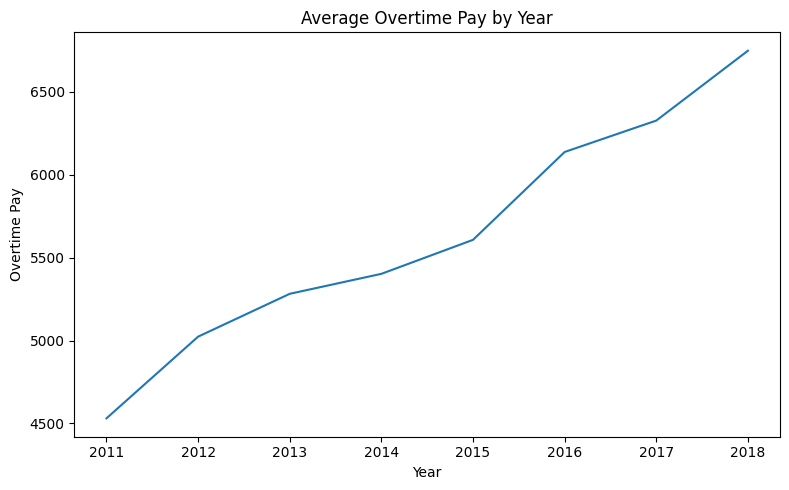

In [116]:
overtime_trend = df.groupby('Year')['OvertimePay'].mean()

plt.figure(figsize=(8,5))
plt.plot(overtime_trend)
plt.title('Average Overtime Pay by Year')
plt.xlabel('Year')
plt.ylabel('Overtime Pay')
plt.tight_layout()
plt.show()

Correlation Analysis

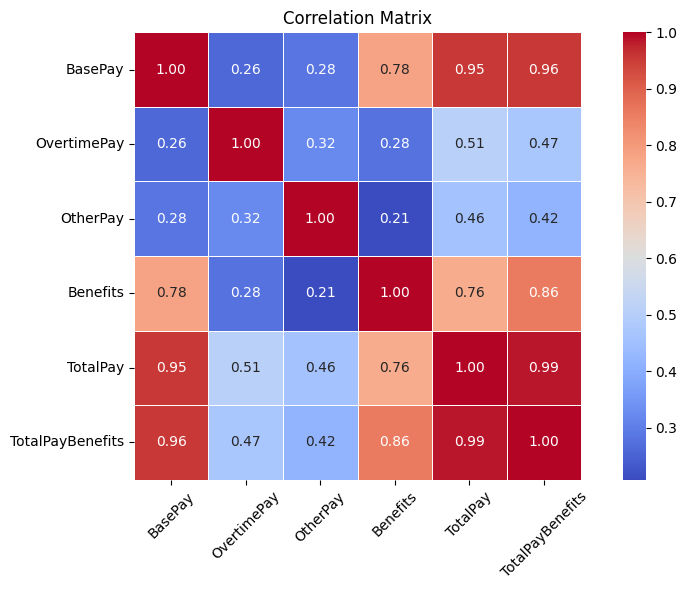

In [117]:
numeric_df = df[['BasePay','OvertimePay','OtherPay','Benefits','TotalPay','TotalPayBenefits']]

corr = numeric_df.corr()

plt.figure(figsize=(9,6))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.tight_layout()
plt.show()



Machine Learning

In [118]:
features = ['BasePay', 'OvertimePay', 'OtherPay', 'Benefits']
target = 'TotalPayBenefits'

X = df[features].fillna(0)
y = df[target]

 Train-Test Split

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Linear Regression

In [120]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\nLinear Regression Results")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))


Linear Regression Results
MAE: 3.1431205047109415e-11
R2 Score: 1.0


Random Forest

In [122]:
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF R2:", r2_score(y_test, rf_pred))

RF R2: 0.9991458335614735


 Prediction Visualization

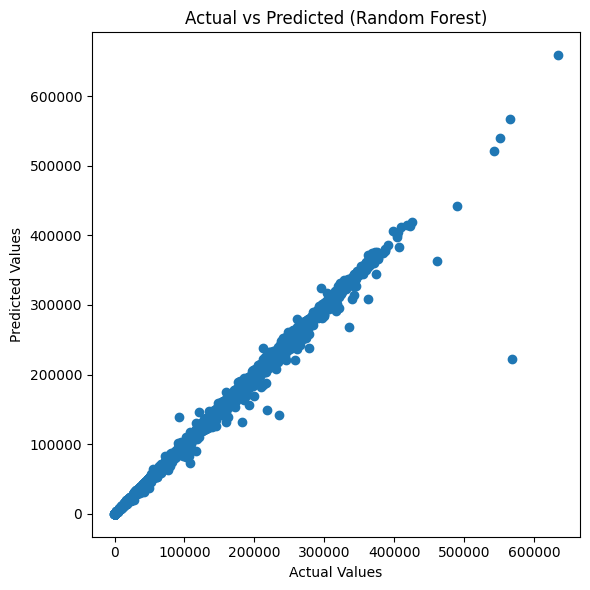

In [123]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted (Random Forest)')
plt.tight_layout()
plt.show()


Feature Importance

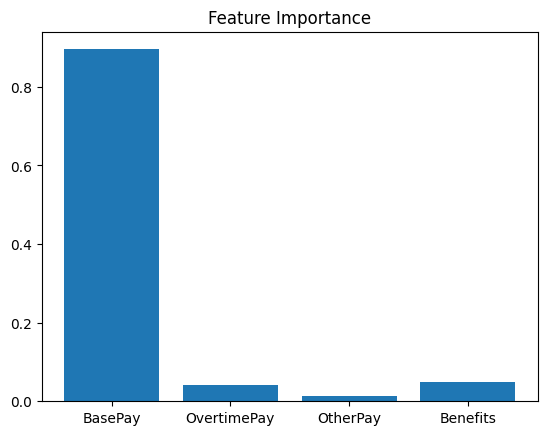

In [124]:
importance = rf.feature_importances_

plt.bar(features, importance)
plt.title('Feature Importance')
plt.show()

 Final Insights



* Average employee compensation increased by approximately 15 - 20% from 2011 to 2018, indicating steady payroll expansion.The growth trend suggests increasing labor costs and possible expansion in workforce or pay revisions.


* Overtime contributes nearly 6% to 8% of Total Pay on average, with an increasing trend over the years.
Certain job roles (e.g., operational, emergency, and field roles) show significantly higher overtime dependency, indicating workload imbalance or staffing gaps.


*   Top overtime-heavy roles earn 30 - 50% of their total pay from overtime, making overtime a critical compensation driver for these positions.

*  Top-paying job titles earn 2 - 3x higher than the average salary, showing strong pay concentration in specialized roles.


*   Salary distribution is right-skewed, with a small number of employees earning extremely high salaries.
*   Employee compensation is steadily increasing, driven primarily by BasePay.


*   Overtime is a critical cost driver for specific job categories and may indicate operational inefficiencies.






